# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

from sklearn.metrics import mean_squared_error

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Import Data

In [2]:
df = pd.read_csv('train.csv')

# Feature Engineering

In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

df_transaction = df[['Order Date', 'Sales']].copy()

df_transaction['month'] = df['Order Date'].dt.month
df_transaction['year'] = df['Order Date'].dt.year
df_transaction['yearmonth'] = df['Order Date'].dt.to_period('M')

df_sales_per_month = df_transaction.groupby('yearmonth')['Sales'].sum().reset_index()

df_sales_per_month['yearmonth'] = df_sales_per_month['yearmonth'].dt.to_timestamp()

In [4]:
df_sales_per_month

,yearmonth,Sales
0,2015-01-01,14205.7070
1,2015-02-01,4519.8920
2,2015-03-01,55205.7970
3,2015-04-01,27906.8550
4,2015-05-01,23644.3030
5,2015-06-01,34322.9356
6,2015-07-01,33781.5430
7,2015-08-01,27117.5365
8,2015-09-01,81623.5268
9,2015-10-01,31453.3930


In [5]:
# Create additional features for the Regressor
def create_features(df_input):
    df = df_input.copy()

    df['year'] = df['yearmonth'].dt.year
    df['month'] = df['yearmonth'].dt.month
    df['quarter'] = df['yearmonth'].dt.quarter
    df['sales_hm'] = df['Sales'].shift(12)
    # df['sales_hm'] = df['sales_hm'].fillna(df['Sales'].mean())
    df['sales_prev_1m'] = df['Sales'].shift(1)
    df['sales_prev_2m'] = df['Sales'].shift(2)
    df['sales_prev_3m'] = df['Sales'].shift(3)
    df['sales_prev_6m'] = df['Sales'].shift(6)
    return df

In [26]:
df_sales_per_month['Sales'].rolling(window=12).mean()

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
5              NaN
6              NaN
7              NaN
8              NaN
9              NaN
10             NaN
11    39988.017342
12    40309.788225
13    40929.081475
14    39023.541592
15    39544.176050
16    40070.445008
17    39176.814875
18    38745.707875
19    39554.108350
20    38013.281617
21    37976.476992
22    37754.955225
23    38286.333783
24    38325.961567
25    39244.911900
26    40813.723617
27    41190.831825
28    43415.613283
29    44759.372617
30    45568.749617
31    45045.737792
32    45550.719867
33    47931.661158
34    48249.752517
35    50016.045833
36    52093.877750
37    51839.059617
38    52480.589100
39    52219.101025
40    51149.857208
41    51855.377350
42    52397.404100
43    55088.708075
44    56501.999500
45    57990.757683
46    61230.062617
47    60171.001600
Name: Sales, dtype: float64

In [6]:
# code to add the avg_sales_prev_year
# yearly_avg_sales = df_sales_per_month.groupby('year')['Sales'].mean().reset_index()
# yearly_avg_sales.rename(columns={'Sales': 'annual_avg_sales'}, inplace=True)

# yearly_avg_sales['year'] = yearly_avg_sales['year'] + 1 # Shift the 'year' column
# yearly_avg_sales.rename(columns={'annual_avg_sales': 'prev_year_avg_sales'}, inplace=True) # Rename for clarity

# df_sales_per_month = pd.merge(df_sales_per_month, yearly_avg_sales, on='year', how='left')

# # df_sales_per_month['prev_year_avg_sales'] = df_sales_per_month['prev_year_avg_sales'].fillna(df_sales_per_month['prev_year_avg_sales'].mean())

In [7]:
df_sales_per_month = create_features(df_sales_per_month)

In [8]:
df_sales_per_month

,yearmonth,Sales,year,month,quarter,sales_hm,sales_prev_1m,sales_prev_2m,sales_prev_3m,sales_prev_6m
0,2015-01-01,14205.7070,2015,1,1,NaN,NaN,NaN,NaN,NaN
1,2015-02-01,4519.8920,2015,2,1,NaN,14205.7070,NaN,NaN,NaN
2,2015-03-01,55205.7970,2015,3,1,NaN,4519.8920,14205.7070,NaN,NaN
3,2015-04-01,27906.8550,2015,4,2,NaN,55205.7970,4519.8920,14205.7070,NaN
4,2015-05-01,23644.3030,2015,5,2,NaN,27906.8550,55205.7970,4519.8920,NaN
5,2015-06-01,34322.9356,2015,6,2,NaN,23644.3030,27906.8550,55205.7970,NaN
6,2015-07-01,33781.5430,2015,7,3,NaN,34322.9356,23644.3030,27906.8550,14205.7070
7,2015-08-01,27117.5365,2015,8,3,NaN,33781.5430,34322.9356,23644.3030,4519.8920
8,2015-09-01,81623.5268,2015,9,3,NaN,27117.5365,33781.5430,34322.9356,55205.7970
9,2015-10-01,31453.3930,2015,10,4,NaN,81623.5268,27117.5365,33781.5430,27906.8550


# Train Test Split

In [9]:
train = df_sales_per_month.loc[df_sales_per_month['yearmonth'] < '2018-01-01'].copy()

test = df_sales_per_month.loc[df_sales_per_month['yearmonth'] >= '2018-01-01'].copy()

# we must set the lag variables of the test set to -1 to avoid leaking
test['sales_prev_1m'] = -1
test['sales_prev_2m'] = -1
test['sales_prev_3m'] = -1
test['sales_prev_6m'] = -1

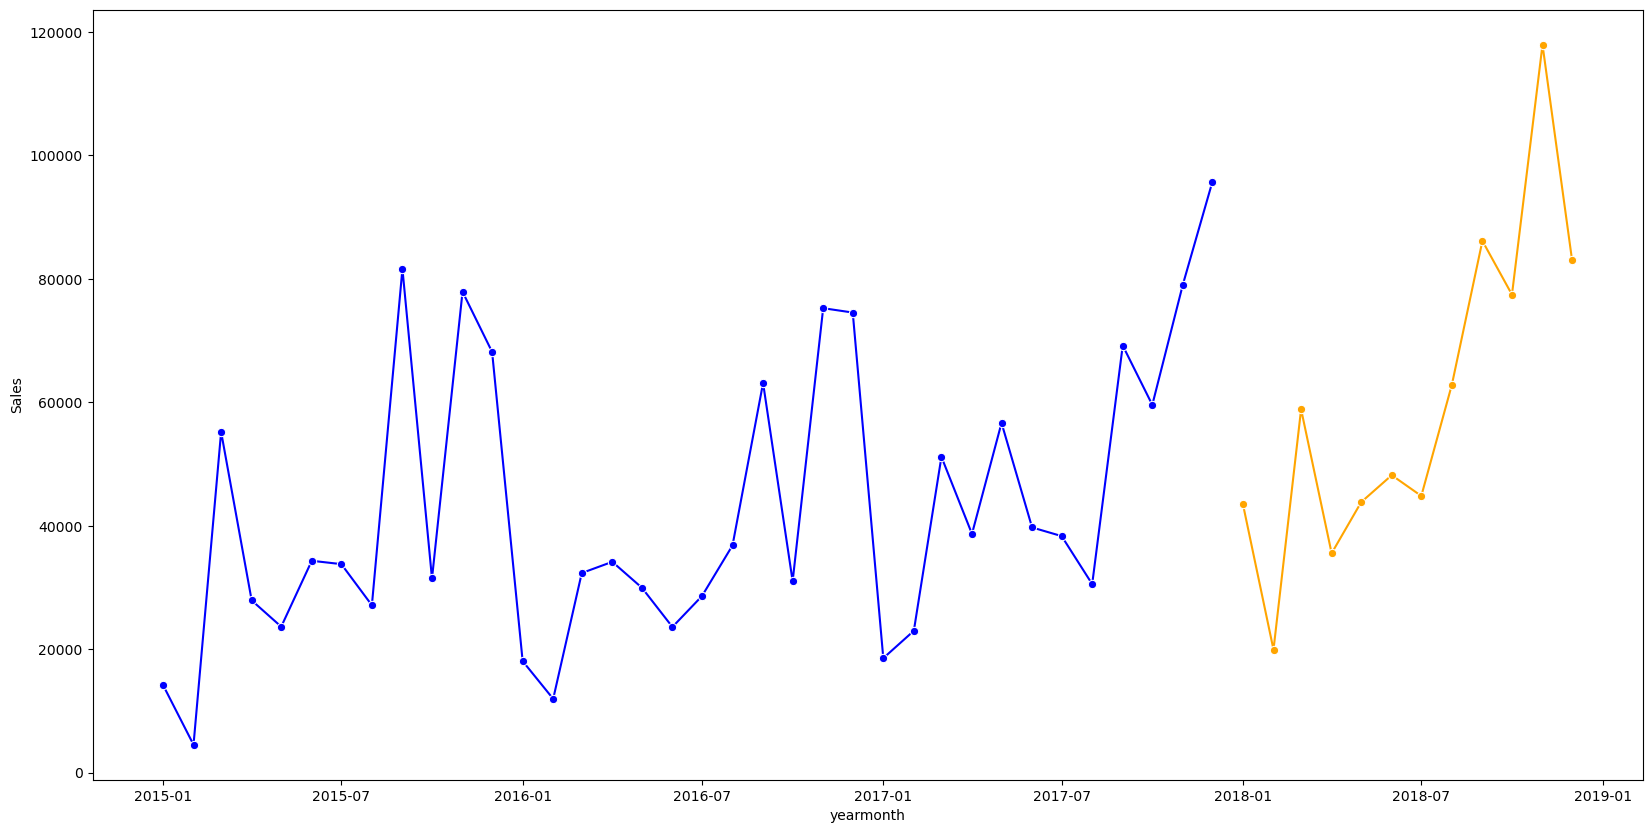

In [10]:
plt.figure(figsize=(20,10))
sns.lineplot(x=train['yearmonth'], y=train['Sales'], marker='o', color='blue')
sns.lineplot(x=test['yearmonth'], y=test['Sales'], marker='o', color='orange')
plt.show()

# Modeling

In [11]:
features = df_sales_per_month.drop(['yearmonth' ,'Sales'], axis=1).columns
target = 'Sales'

In [12]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [13]:
model = xgb.XGBRegressor(random_state=10)

param_grid = {
    'n_estimators': [500, 1000, 1500], # Fewer estimators for faster initial run
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=tscv, # Use the time series cross-validator
    scoring='neg_mean_squared_error', # Optimize for RMSE (negative MSE)
    verbose=100, # Set to higher for more details during search
    n_jobs=-1 # Use all available CPU cores
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

Fitting 3 folds for each of 108 candidates, totalling 324 fits


# Feature Importance

In [14]:
feat_importances = pd.DataFrame(data = best_model.feature_importances_, index = best_model.feature_names_in_, columns = ['importance'])

<Axes: title={'center': 'Feature Importance'}>

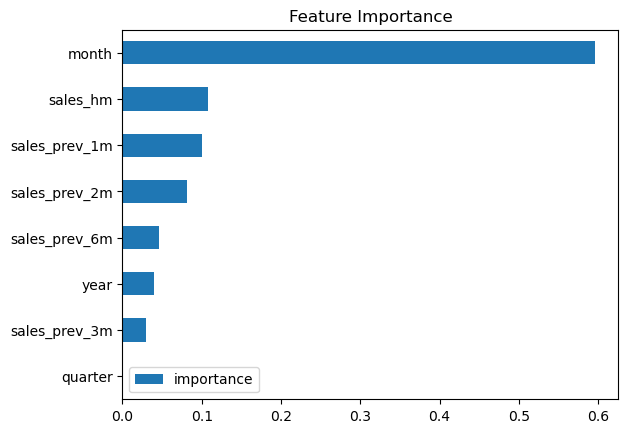

In [15]:
feat_importances.sort_values('importance').plot(kind='barh', title='Feature Importance')

# Forecast Test Set - One Shot

In [16]:
test['prediction'] = best_model.predict(X_test)

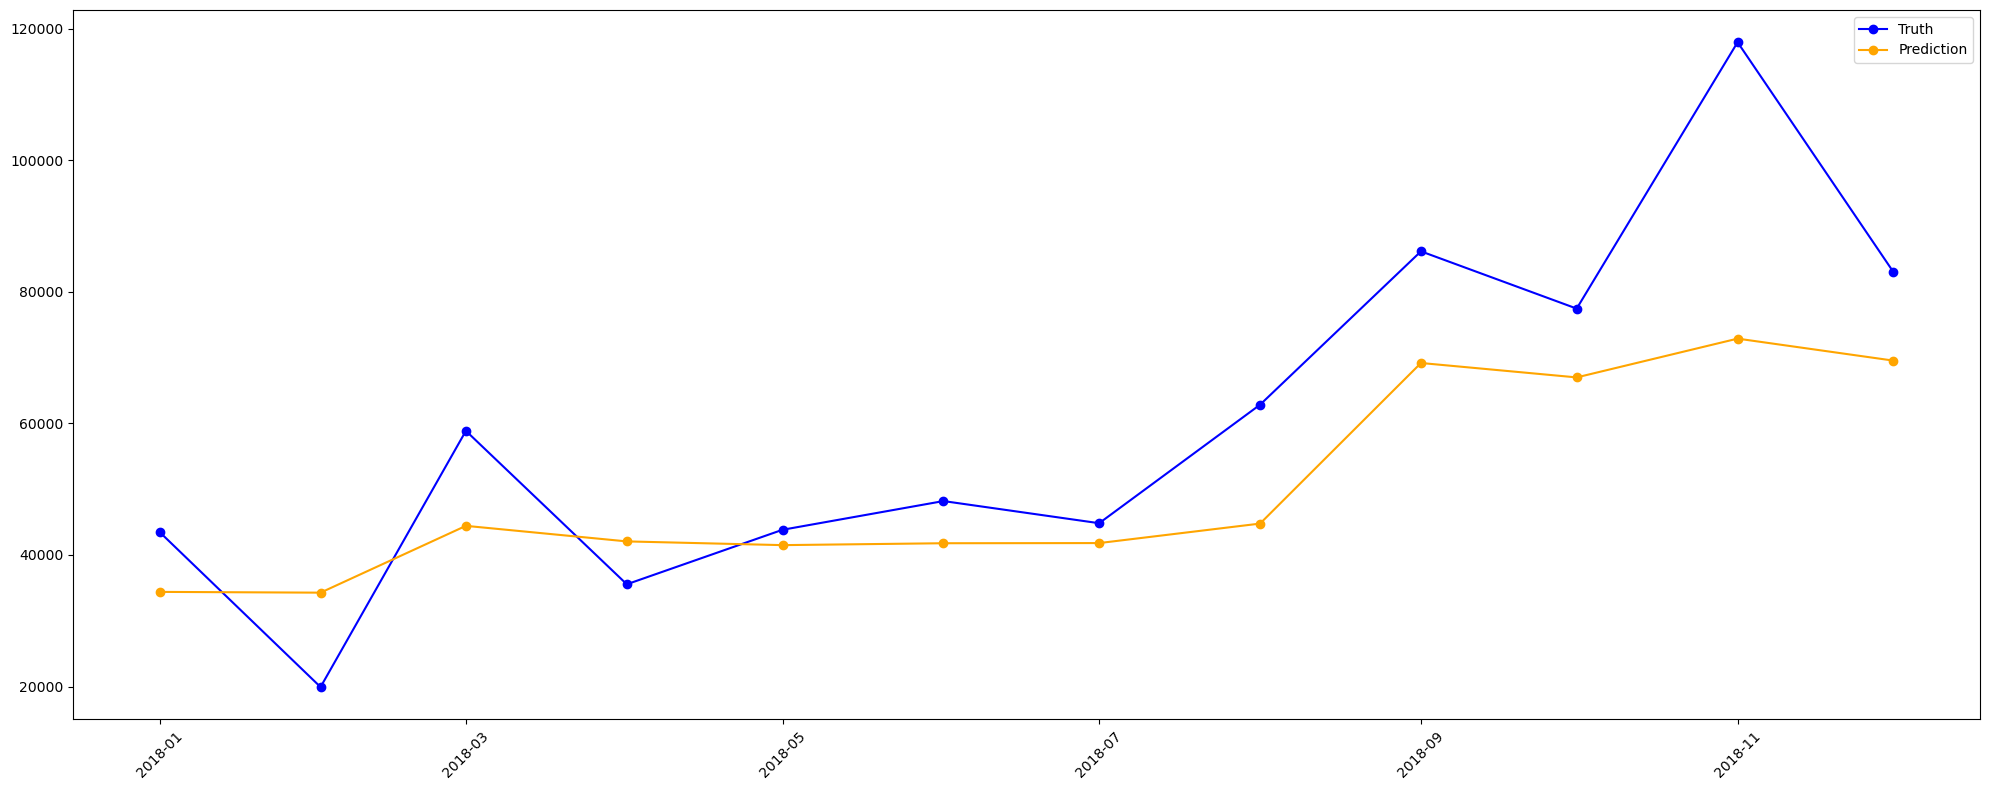

In [17]:
plt.figure(figsize=(20, 8))

# Plotting the time series
plt.plot(test['yearmonth'], test['Sales'], marker='o', linestyle='-', color='blue', label='Truth')
plt.plot(test['yearmonth'], test['prediction'], marker = 'o', linestyle='-', color='orange', label='Prediction')

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Adding the legend
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()

In [18]:
mse = mean_squared_error(test['Sales'], test['prediction'])
rmse = np.sqrt(mse)
print(f'RMSE on Test Set: {rmse}')

RMSE on Test Set: 17153.587778940335


# Forecast Test Set - Multi Step

In [19]:
# create the lag features that are dependent of the training set
test.loc[test.index[0], 'sales_prev_1m'] = train['Sales'].iloc[-1]
test.loc[test.index[0], 'sales_prev_2m'] = train['Sales'].iloc[-2] 
test.loc[test.index[0], 'sales_prev_3m'] = train['Sales'].iloc[-3] 
test.loc[test.index[0], 'sales_prev_6m'] = train['Sales'].iloc[-6]

test.loc[test.index[1], 'sales_prev_2m'] = train['Sales'].iloc[-1]
test.loc[test.index[1], 'sales_prev_3m'] = train['Sales'].iloc[-2]
test.loc[test.index[1], 'sales_prev_6m'] = train['Sales'].iloc[-5]

test.loc[test.index[2], 'sales_prev_3m'] = train['Sales'].iloc[-1]
test.loc[test.index[2], 'sales_prev_6m'] = train['Sales'].iloc[-4]

test.loc[test.index[3], 'sales_prev_6m'] = train['Sales'].iloc[-3]
test.loc[test.index[4], 'sales_prev_6m'] = train['Sales'].iloc[-2]
test.loc[test.index[5], 'sales_prev_6m'] = train['Sales'].iloc[-1]

C:\Users\User\AppData\Local\Temp\ipykernel_16304\586961646.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '95739.121' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test.loc[test.index[0], 'sales_prev_1m'] = train['Sales'].iloc[-1]
C:\Users\User\AppData\Local\Temp\ipykernel_16304\586961646.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '79066.4958' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test.loc[test.index[0], 'sales_prev_2m'] = train['Sales'].iloc[-2]
C:\Users\User\AppData\Local\Temp\ipykernel_16304\586961646.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '59583.033' has dtype incompatible with int64, please explicitly cast to a compatibl

In [20]:
predictions = []
for i in range(len(test)):
    # Prepare the input data for the model (features including lag values)
    X_current = test.iloc[i][features].values.reshape(1, -1)
    
    # Make the prediction for the current month
    sales_pred = best_model.predict(X_current)[0]
    predictions.append(sales_pred)
    
    # Update the lag features for the next iteration (next month)
    if i + 1 < len(test):
        test.loc[test.index[i + 1], 'sales_prev_1m'] = sales_pred  # sales_prev_1m becomes the current month's prediction
        test.loc[test.index[i + 1], 'sales_prev_2m'] = test.loc[test.index[i], 'sales_prev_1m']  # previous sales become lag values
        test.loc[test.index[i + 1], 'sales_prev_3m'] = test.loc[test.index[i], 'sales_prev_2m']
        test.loc[test.index[i + 1], 'sales_prev_6m'] = test.loc[test.index[i], 'sales_prev_3m']

    # After the loop, we have the predictions for the test set
test['prediction'] = predictions

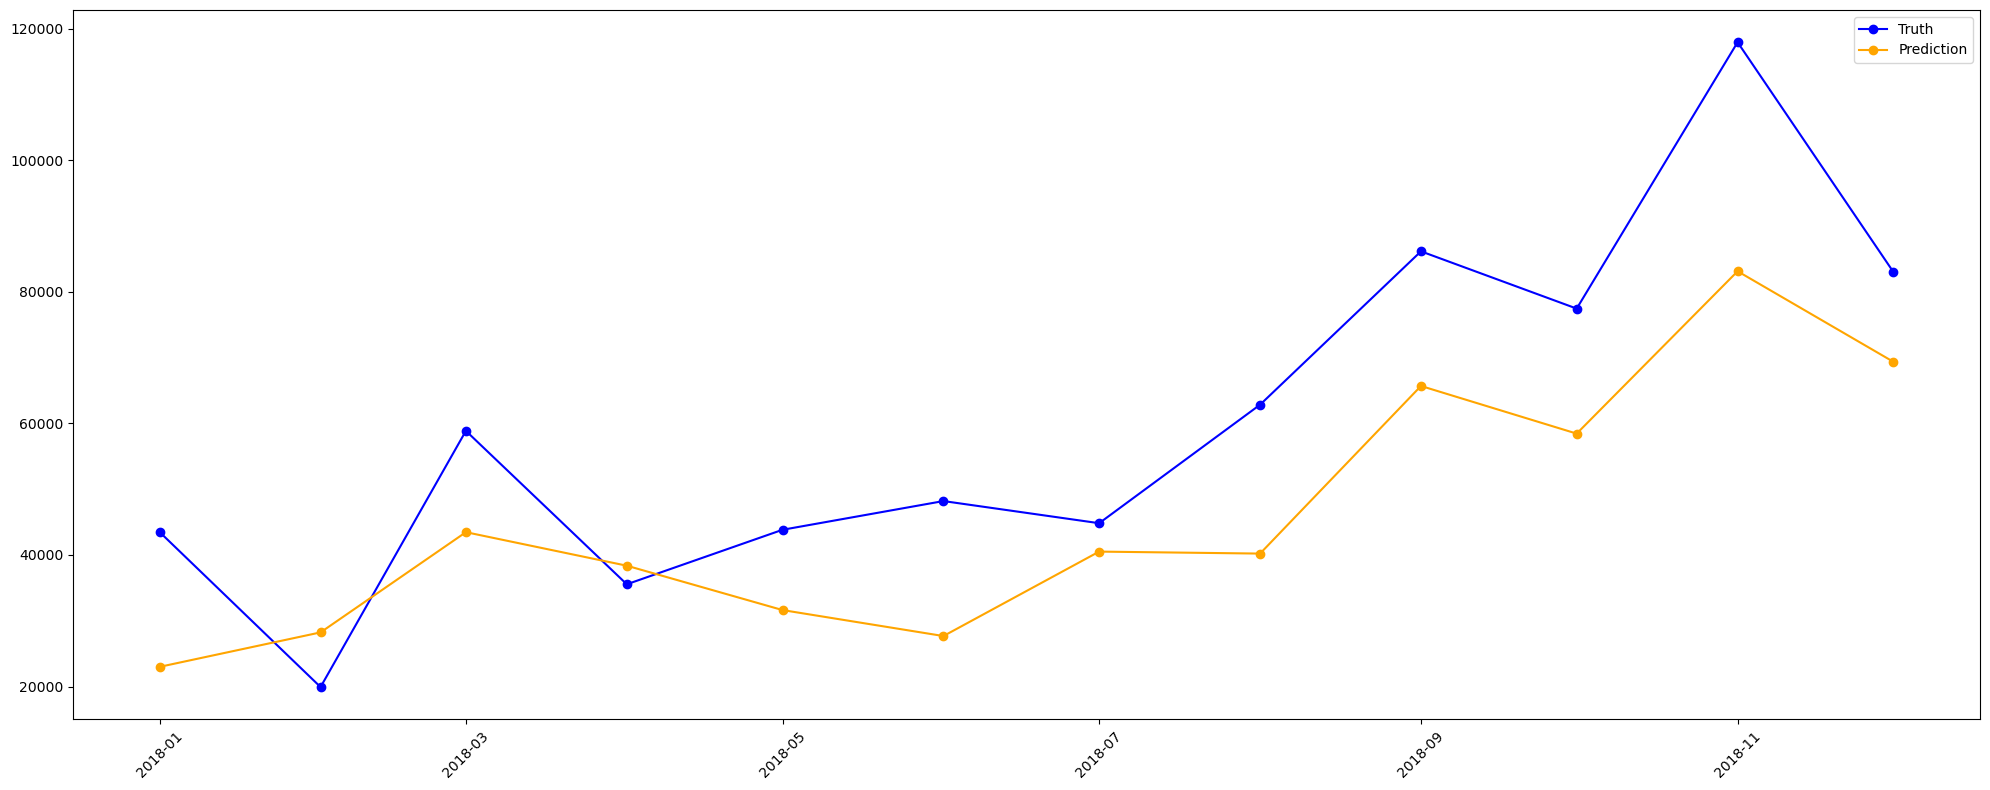

In [21]:
plt.figure(figsize=(20, 8))

# Plotting the time series
plt.plot(test['yearmonth'], test['Sales'], marker='o', linestyle='-', color='blue', label='Truth')
plt.plot(test['yearmonth'], test['prediction'], marker = 'o', linestyle='-', color='orange', label='Prediction')

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Adding the legend
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()

In [22]:
mse = mean_squared_error(test['Sales'], test['prediction'])
rmse = np.sqrt(mse)
print(f'RMSE on Test Set: {rmse}')

RMSE on Test Set: 18287.544245043988
